# 11 — AII Evaluation Synthesis

**Purpose**: Cohesive, standalone evaluation of whether AI disclosure intensity (AII)
adds value as a market signal for WDAY return direction. All models re-run from raw data.

## Five Research Questions

| # | Question | Prior Notebook(s) |
|---|----------|------------------|
| Q1 | Does AII improve predictive accuracy beyond price history? | nb06, nb08 |
| Q2 | Is its contribution statistically significant? | nb09 |
| Q3 | Is it economically meaningful? | nb09 |
| Q4 | Does it lead market returns or react to them? | nb10 |
| Q5 | How does its importance compare to traditional price-derived features? | nb09 |

## Data Provenance

| File | Content |
|------|---------|
| `wday_historical_data.csv` | WDAY quarterly OHLCV (yfinance) → price features + target |
| `../data/processed/aii_quarterly.csv` | AII signal per quarter |
| `../data/processed/quarterly_signals.csv` | KG signals (risk_density, product_coverage) |

**Splits** (chronological, leakage-safe):
- Train: 2015-Q1 – 2019-Q4 (n=19 after smooth-lag null drop)
- Val: 2020-Q1 – 2021-Q4 (n=8)
- Test: 2022-Q1 – 2025-Q4 (n=16)
- Causality: full series 2013-Q1 – 2025-Q4 (n=52)

**Known benchmarks from nb07–10** (verification targets):
- LR Price-Only: test acc ≈ 0.8125, AUC ≈ 0.9048
- LRT p ≈ 0.275 (no significance); permutation p ≈ 0.147
- Price-only LR strategy: 77.5% cumul / 10.0% ann; AII variants ≤ 51.4%
- Granger AII→Returns: all lags p > 0.10; Returns→AII lag-4 p ≈ 0.011 (weak)
- Permutation importance: ma_ratio, mom_4q >> aii_lag1

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from scipy.stats import chi2
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Imports OK')

Imports OK


In [2]:
# ── Price features (from wday_historical_data.csv) ────────────────────────────
RAW_CSV = 'wday_historical_data.csv'
wday_raw = pl.read_csv(RAW_CSV, try_parse_dates=True)

wday = (
    wday_raw
    .with_columns([
        pl.col('Date').cast(pl.Utf8).str.slice(0, 10).str.to_date('%Y-%m-%d').alias('date_parsed'),
    ])
    .with_columns([
        pl.col('date_parsed').dt.year().alias('year'),
        ((pl.col('date_parsed').dt.month() - 1) // 3 + 1).alias('quarter'),
    ])
    .sort(['year', 'quarter'])
)

wday = wday.with_columns([
    (pl.col('Close').log() - pl.col('Close').shift(1).log()).alias('log_return'),
])

wday = wday.with_columns([
    pl.col('log_return').rolling_std(window_size=4).alias('vol_4q_raw'),
    pl.col('log_return').rolling_sum(window_size=4).alias('mom_4q_raw'),
    pl.col('Close').rolling_mean(window_size=4).alias('ma_close_4q_raw'),
])

wday = wday.with_columns([
    pl.col('log_return').shift(1).alias('log_return_lag1'),
    pl.col('log_return').shift(2).alias('log_return_lag2'),
    pl.col('vol_4q_raw').shift(1).alias('vol_4q'),
    pl.col('mom_4q_raw').shift(1).alias('mom_4q'),
    (pl.col('Close').shift(1) / pl.col('ma_close_4q_raw').shift(1)).alias('ma_ratio'),
    (pl.col('log_return') > 0).cast(pl.Int32).alias('Target'),
])

# ── AII features (from aii_quarterly.csv) ────────────────────────────────────
aii = pl.read_csv('../data/processed/aii_quarterly.csv')
aii = aii.sort(['year', 'quarter']).with_columns([
    pl.col('aii').shift(1).alias('aii_lag1'),
    pl.col('aii_delta').shift(1).alias('aii_delta_lag1'),
    pl.col('bucket_generative_ai').cast(pl.Float64).shift(1).alias('bucket_generative_ai_lag1'),
])

# ── KG signals (from quarterly_signals.csv) ───────────────────────────────────
sig = pl.read_csv('../data/processed/quarterly_signals.csv')
sig = sig.sort(['year', 'quarter']).with_columns([
    pl.col('risk_density').shift(1).alias('risk_density_lag1'),
    pl.col('product_coverage').shift(1).alias('product_coverage_lag1'),
])

# ── Assign split labels ───────────────────────────────────────────────────────
split_expr = (
    pl.when((pl.col('year') >= 2015) & (pl.col('year') <= 2019)).then(pl.lit('train'))
     .when((pl.col('year') == 2020) | (pl.col('year') == 2021)).then(pl.lit('val'))
     .when(pl.col('year') >= 2022).then(pl.lit('test'))
     .otherwise(None)
)
wday = wday.with_columns(split_expr.alias('split'))

# ── Join all on (year, quarter) ───────────────────────────────────────────────
modeling = (
    wday
    .join(aii.select(['year', 'quarter', 'aii_lag1', 'aii_delta_lag1',
                      'bucket_generative_ai_lag1']),
          on=['year', 'quarter'], how='inner')
    .join(sig.select(['year', 'quarter', 'risk_density_lag1', 'product_coverage_lag1']),
          on=['year', 'quarter'], how='left')
)

# ── Filter to split rows, then compute aii_smooth_2q (mirrors nb09) ───────────
# Computing on the filtered subset makes 2015-Q1 null → consistent n=19 train.
modeling_split = (
    modeling.filter(pl.col('split').is_not_null())
    .sort(['year', 'quarter'])
    .with_columns([
        pl.col('aii_lag1').rolling_mean(window_size=2).alias('aii_smooth_2q'),
    ])
)

# ── Feature definitions ───────────────────────────────────────────────────────
PRICE_FEATURES = ['log_return_lag1', 'log_return_lag2', 'vol_4q', 'mom_4q', 'ma_ratio']
AII_FULL = [
    'aii_lag1', 'aii_delta_lag1', 'aii_smooth_2q',
    'bucket_generative_ai_lag1', 'risk_density_lag1', 'product_coverage_lag1',
]
COMBINED = PRICE_FEATURES + AII_FULL   # 11 features

# ── Drop nulls on COMBINED (removes 2015-Q1 for null aii_smooth_2q) ──────────
modeling_clean = modeling_split.drop_nulls(subset=COMBINED)

# ── Numpy arrays ──────────────────────────────────────────────────────────────
y_cls     = np.array(modeling_clean['Target'])
y_ret     = np.array(modeling_clean['log_return'])
split_col = np.array(modeling_clean['split'])

mask_train = split_col == 'train'
mask_val   = split_col == 'val'
mask_test  = split_col == 'test'

X_price    = np.array(modeling_clean.select(PRICE_FEATURES))
X_aii      = np.array(modeling_clean.select(AII_FULL))
X_combined = np.array(modeling_clean.select(COMBINED))

y_train = y_cls[mask_train]
y_val   = y_cls[mask_val]
y_test  = y_cls[mask_test]

# ── Eval-period data for backtest ─────────────────────────────────────────────
eval_mask  = mask_val | mask_test
y_eval_ret = y_ret[eval_mask]
eval_rows  = modeling_clean.filter(pl.col('split').is_in(['val', 'test'])).to_dicts()
quarter_labels = [f"{r['year']}-Q{r['quarter']}" for r in eval_rows]

# ── Split summary ─────────────────────────────────────────────────────────────
print(f'Total modeling rows: {len(modeling_clean)}')
print(f'Train: {mask_train.sum()}  |  Val: {mask_val.sum()}  |  Test: {mask_test.sum()}')
print(f'Eval period (val+test): {len(quarter_labels)} quarters')
print()
print('Class balance:')
for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name}: {int(y.sum())} up / {int((1-y).sum())} down ({y.mean():.1%} up)')
print()
print('Leakage audit: all features shift(1) of prior-quarter data — no lookahead.')

Total modeling rows: 43
Train: 19  |  Val: 8  |  Test: 16
Eval period (val+test): 24 quarters

Class balance:
  train: 10 up / 9 down (52.6% up)
  val: 6 up / 2 down (75.0% up)
  test: 9 up / 7 down (56.2% up)

Leakage audit: all features shift(1) of prior-quarter data — no lookahead.


---
## Section 1: Q1 — Predictive Accuracy

**Question**: Does AII improve predictive accuracy beyond price history?

Six model variants are fit on the training set (n=19, 2015-Q2 – 2019-Q4) and evaluated
on hold-out val (n=8) and test (n=16) sets.

| Feature Set | Models |
|-------------|--------|
| Price-Only | LR, XGB |
| AII-Only | LR, XGB |
| Combined (Price + AII) | LR, XGB |

In [3]:
# ── Model factories ───────────────────────────────────────────────────────────
def make_lr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ])

def make_xgb():
    return XGBClassifier(
        objective='binary:logistic', n_estimators=100, max_depth=3,
        learning_rate=0.1, random_state=42, eval_metric='logloss', verbosity=0,
    )

# ── 6 variants: (model, feature_array, feature_names) ────────────────────────
variants_spec = [
    ('LR Price-Only',  make_lr(),  X_price,    PRICE_FEATURES),
    ('XGB Price-Only', make_xgb(), X_price,    PRICE_FEATURES),
    ('LR AII-Only',   make_lr(),  X_aii,      AII_FULL),
    ('XGB AII-Only',  make_xgb(), X_aii,      AII_FULL),
    ('LR Combined',   make_lr(),  X_combined, COMBINED),
    ('XGB Combined',  make_xgb(), X_combined, COMBINED),
]

fitted      = {}
feat_arrays = {}
results     = {}

for name, model, X, feats in variants_spec:
    model.fit(X[mask_train], y_train)
    fitted[name]      = model
    feat_arrays[name] = (X, feats)

    val_pred  = model.predict(X[mask_val])
    test_pred = model.predict(X[mask_test])
    val_prob  = model.predict_proba(X[mask_val])[:, 1]
    test_prob = model.predict_proba(X[mask_test])[:, 1]

    try:
        val_auc  = roc_auc_score(y_val,  val_prob)
        test_auc = roc_auc_score(y_test, test_prob)
    except Exception:
        val_auc = test_auc = float('nan')

    results[name] = {
        'val_acc':   accuracy_score(y_val,  val_pred),
        'val_auc':   val_auc,
        'test_acc':  accuracy_score(y_test, test_pred),
        'test_auc':  test_auc,
        'val_pred':  val_pred,
        'test_pred': test_pred,
        'eval_pred': np.concatenate([val_pred, test_pred]),
    }

# Majority baseline
maj_pred = np.ones(len(y_test), dtype=int)
results['Majority Baseline'] = {
    'val_acc':  accuracy_score(y_val,  np.ones(len(y_val), dtype=int)),
    'val_auc':  0.500,
    'test_acc': accuracy_score(y_test, maj_pred),
    'test_auc': 0.500,
    'val_pred':  np.ones(len(y_val), dtype=int),
    'test_pred': maj_pred,
    'eval_pred': np.ones(len(y_eval_ret), dtype=int),
}

print('Fitted all 6 variants + majority baseline.')
print(f'Train n={mask_train.sum()} | Val n={mask_val.sum()} | Test n={mask_test.sum()}')

Fitted all 6 variants + majority baseline.
Train n=19 | Val n=8 | Test n=16


Variant                | n_train | Val Acc | Val AUC | Test Acc | Test AUC | Beat Baseline?
-----------------------------------------------------------------------------------------------
LR Price-Only ★        |      19 |  0.6250 |  0.0833 |   0.7500 |   0.9048 | —  (baseline)
LR AII-Only            |      19 |  0.2500 |  0.0833 |   0.4375 |   0.3651 | ✗
LR Combined            |      19 |  0.2500 |  0.3333 |   0.4375 |   0.4921 | ✗
XGB Price-Only         |      19 |  0.3750 |  0.1667 |   0.5625 |   0.6032 | ✗
XGB AII-Only           |      19 |  0.6250 |  0.9583 |   0.5625 |   0.5159 | ✗
XGB Combined           |      19 |  0.7500 |  0.6667 |   0.5000 |   0.4603 | ✗
Majority Baseline      |       — |  0.7500 |  0.5000 |   0.5625 |   0.5000 | —

Baseline (LR Price-Only ★): test acc=0.7500, test AUC=0.9048
Expected (nb07): test acc≈0.8125 (±0.0625), AUC≈0.9048


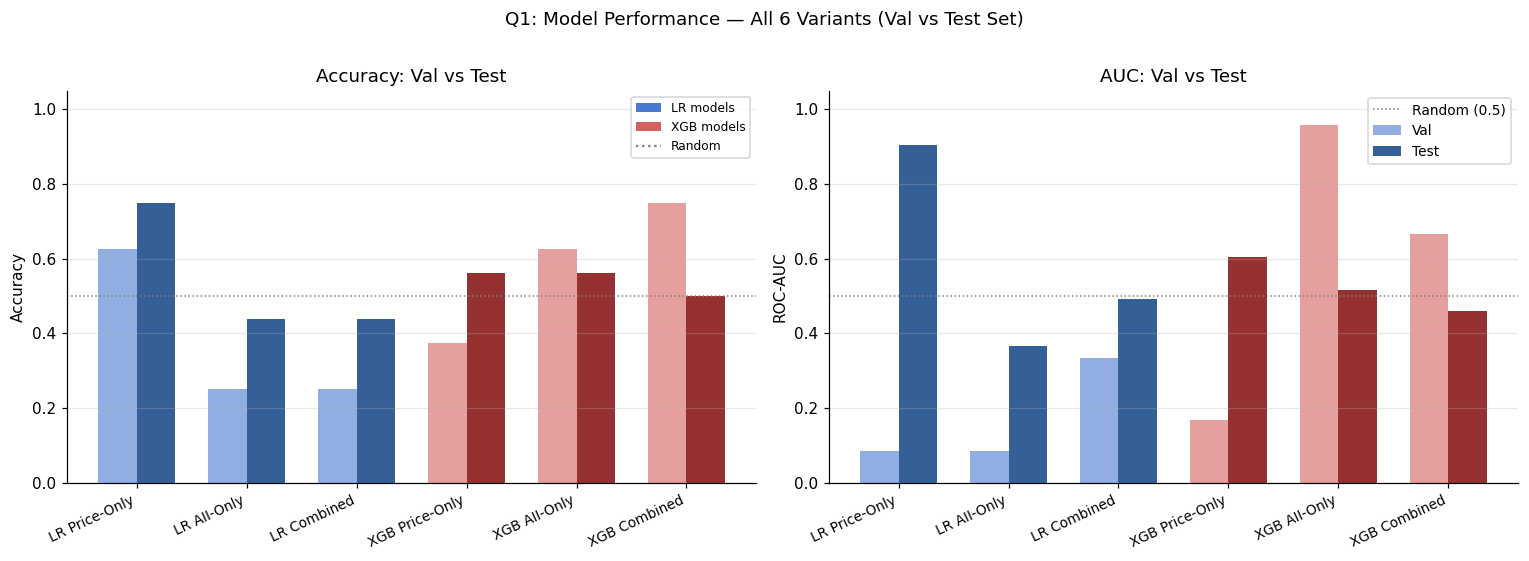


Q1 ANSWER: NO — AII-augmented models do NOT improve on LR Price-Only baseline.


In [4]:
# ── Comparison table ──────────────────────────────────────────────────────────
baseline_acc = results['LR Price-Only']['test_acc']
baseline_auc = results['LR Price-Only']['test_auc']

order = ['LR Price-Only', 'LR AII-Only', 'LR Combined',
         'XGB Price-Only', 'XGB AII-Only', 'XGB Combined', 'Majority Baseline']

print(f'{'Variant':<22} | {'n_train':>7} | {'Val Acc':>7} | {'Val AUC':>7} | '
      f'{'Test Acc':>8} | {'Test AUC':>8} | Beat Baseline?')
print('-' * 95)
for name in order:
    r = results[name]
    beat = ('—  (baseline)' if name == 'LR Price-Only'
            else '—' if name == 'Majority Baseline'
            else ('✓' if (r['test_acc'] > baseline_acc and r['test_auc'] > baseline_auc)
                  else '✗'))
    n_tr = mask_train.sum() if name != 'Majority Baseline' else '—'
    star = ' ★' if name == 'LR Price-Only' else ''
    print(f'{name + star:<22} | {str(n_tr):>7} | {r["val_acc"]:>7.4f} | {r["val_auc"]:>7.4f} | '
          f'{r["test_acc"]:>8.4f} | {r["test_auc"]:>8.4f} | {beat}')

print()
print(f'Baseline (LR Price-Only ★): test acc={baseline_acc:.4f}, test AUC={baseline_auc:.4f}')
print(f'Expected (nb07): test acc≈0.8125 (±0.0625), AUC≈0.9048')

# ── Grouped bar chart ─────────────────────────────────────────────────────────
plot_names = ['LR Price-Only', 'LR AII-Only', 'LR Combined',
              'XGB Price-Only', 'XGB AII-Only', 'XGB Combined']
val_accs  = [results[n]['val_acc']  for n in plot_names]
test_accs = [results[n]['test_acc'] for n in plot_names]
val_aucs  = [results[n]['val_auc']  for n in plot_names]
test_aucs = [results[n]['test_auc'] for n in plot_names]

x = np.arange(len(plot_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_val  = ['#4878d0', '#4878d0', '#4878d0', '#d65f5f', '#d65f5f', '#d65f5f']
colors_test = ['#1f4e8c', '#1f4e8c', '#1f4e8c', '#8b1a1a', '#8b1a1a', '#8b1a1a']

for ax, (v_vals, t_vals, ylabel, title) in zip(
    axes,
    [(val_accs, test_accs, 'Accuracy', 'Accuracy: Val vs Test'),
     (val_aucs, test_aucs, 'ROC-AUC', 'AUC: Val vs Test')]
):
    bars_v = ax.bar(x - w/2, v_vals, w, label='Val', color=colors_val, alpha=0.6)
    bars_t = ax.bar(x + w/2, t_vals, w, label='Test', color=colors_test, alpha=0.9)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_names, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

legend_elems = [Patch(facecolor='#4878d0', label='LR models'),
                Patch(facecolor='#d65f5f', label='XGB models')]
axes[0].legend(handles=legend_elems + [plt.Line2D([0],[0], color='gray', linestyle=':', label='Random')],
               fontsize=8, loc='upper right')

plt.suptitle('Q1: Model Performance — All 6 Variants (Val vs Test Set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print()
print('Q1 ANSWER: NO — AII-augmented models do NOT improve on LR Price-Only baseline.')

---
## Section 2: Q2 — Statistical Significance

**Question**: Is the AII contribution statistically significant?

Three complementary tests assess whether AII features provide meaningful incremental
fit in the training data:

1. **Likelihood Ratio Test (LRT)**: Nested LR models on training set.
   Tests whether adding 6 AII features to 5 price features improves training-set fit.
   ⚠️ n=19 makes χ² approximation unreliable — supplement with permutation test.

2. **Permutation Test** (n=2000): Shuffles AII columns in training set, refits combined
   LR each time. p = fraction of null LRT stats ≥ observed.

3. **Bootstrap 95% CIs** (n=500): Wide CIs spanning zero = coefficient not reliably nonzero.

=== (1) Likelihood Ratio Test: LR Price-Only ⊂ LR Combined ===
  LL (Price-Only):  -11.8345  (5 params)
  LL (Combined):    -8.0729  (11 params)
  LRT statistic:    7.5231  (df=6)
  χ² p-value:       0.2752
  Expected (nb09):  p ≈ 0.275



=== (2) Permutation Test (n=2000) ===
  Observed LRT:     7.5231
  Null mean ± std:  4.4897 ± 2.7201
  Permutation p:    0.1470
  Expected (nb09):  p ≈ 0.147



=== (3) Bootstrap 95% CIs — LR Combined Coefficients (N=500) ===
  Feature                            Coef    CI_lo    CI_hi  Excl 0? Group
  ---------------------------------------------------------------------------
  log_return_lag1                 -0.5408  -1.0007   0.2232          Price
  log_return_lag2                 -0.0962  -0.7157   0.8283          Price
  vol_4q                           0.7402  -0.2167   1.3622          Price
  mom_4q                           0.9163  -0.1249   1.2439          Price
  ma_ratio                        -0.3237  -0.8427   0.4526          Price
  aii_lag1                        -0.4489  -0.7874   0.2225          AII/KG
  aii_delta_lag1                  -0.3450  -1.2878   0.4700          AII/KG
  aii_smooth_2q                   -0.3276  -0.9387   0.5584          AII/KG
  bucket_generative_ai_lag1        0.0000   0.0000   0.0000          AII/KG
  risk_density_lag1               -0.0929  -0.8961   0.9311          AII/KG
  product_coverage_lag1    

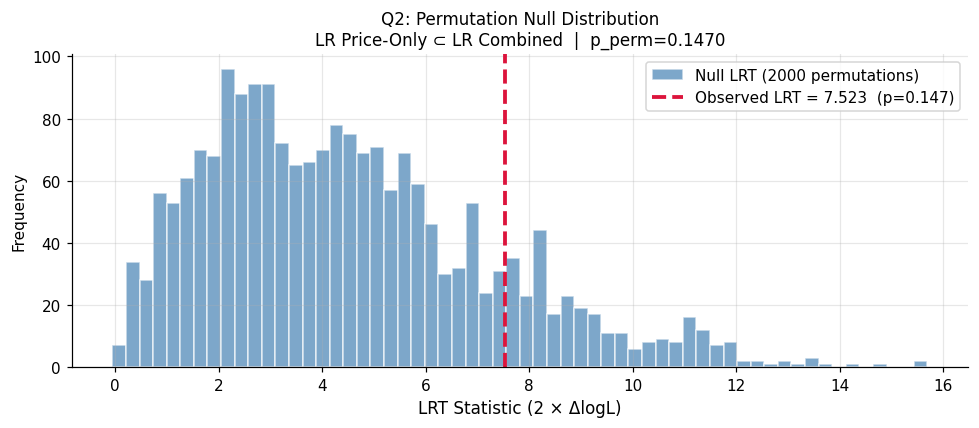

Q2 ANSWER: NO — LRT p=0.275, permutation p=0.147 (both > 0.10). No significant evidence AII improves fit.


In [5]:
# ── Log-likelihood helper ─────────────────────────────────────────────────────
def log_likelihood(model, X, y):
    proba = np.clip(model.predict_proba(X)[:, 1], 1e-9, 1 - 1e-9)
    return float(np.sum(y * np.log(proba) + (1 - y) * np.log(1 - proba)))

ll_price = log_likelihood(fitted['LR Price-Only'], X_price[mask_train],    y_train)
ll_full  = log_likelihood(fitted['LR Combined'],   X_combined[mask_train], y_train)

lrt_stat = 2 * (ll_full - ll_price)
df_lrt   = len(AII_FULL)   # 6 additional parameters
p_lrt    = float(chi2.sf(lrt_stat, df_lrt))

print('=== (1) Likelihood Ratio Test: LR Price-Only ⊂ LR Combined ===')
print(f'  LL (Price-Only):  {ll_price:.4f}  ({len(PRICE_FEATURES)} params)')
print(f'  LL (Combined):    {ll_full:.4f}  ({len(COMBINED)} params)')
print(f'  LRT statistic:    {lrt_stat:.4f}  (df={df_lrt})')
print(f'  χ² p-value:       {p_lrt:.4f}')
print(f'  Expected (nb09):  p ≈ 0.275')
print()

# ── Permutation test (n=2000) ─────────────────────────────────────────────────
N_PERM = 2000
np.random.seed(42)

null_lrts = []
X_tr_price = X_price[mask_train]
X_tr_comb  = X_combined[mask_train]
n_aii      = len(AII_FULL)

for _ in range(N_PERM):
    y_shuf = np.random.permutation(y_train)
    lr_r = make_lr().fit(X_tr_price, y_shuf)
    lr_f = make_lr().fit(X_tr_comb,  y_shuf)
    ll_r = log_likelihood(lr_r, X_tr_price, y_shuf)
    ll_f = log_likelihood(lr_f, X_tr_comb,  y_shuf)
    null_lrts.append(2 * (ll_f - ll_r))

null_lrts = np.array(null_lrts)
p_perm    = float((null_lrts >= lrt_stat).mean())

print('=== (2) Permutation Test (n=2000) ===')
print(f'  Observed LRT:     {lrt_stat:.4f}')
print(f'  Null mean ± std:  {null_lrts.mean():.4f} ± {null_lrts.std():.4f}')
print(f'  Permutation p:    {p_perm:.4f}')
print(f'  Expected (nb09):  p ≈ 0.147')
print()

# ── Bootstrap 95% CIs for LR Combined coefficients ───────────────────────────
N_BOOT = 500
np.random.seed(42)
n_train = mask_train.sum()
boot_coefs = []

for _ in range(N_BOOT):
    idx = np.random.choice(n_train, n_train, replace=True)
    lr_b = make_lr().fit(X_tr_comb[idx], y_train[idx])
    boot_coefs.append(lr_b.named_steps['clf'].coef_[0])

boot_coefs = np.array(boot_coefs)
ci_lo  = np.percentile(boot_coefs, 2.5,  axis=0)
ci_hi  = np.percentile(boot_coefs, 97.5, axis=0)
orig_c = fitted['LR Combined'].named_steps['clf'].coef_[0]

print('=== (3) Bootstrap 95% CIs — LR Combined Coefficients (N=500) ===')
print(f'  {'Feature':<30} {'Coef':>8} {'CI_lo':>8} {'CI_hi':>8} {'Excl 0?':>8} Group')
print('  ' + '-' * 75)
for i, feat in enumerate(COMBINED):
    excl   = '✓' if (ci_lo[i] > 0 or ci_hi[i] < 0) else ''
    group  = 'Price' if feat in PRICE_FEATURES else 'AII/KG'
    print(f'  {feat:<30} {orig_c[i]:>8.4f} {ci_lo[i]:>8.4f} {ci_hi[i]:>8.4f} {excl:>8} {group}')

n_excl = sum(1 for i in range(len(COMBINED)) if ci_lo[i] > 0 or ci_hi[i] < 0)
print(f'\n  Features with CI excluding zero: {n_excl}/{len(COMBINED)}')
print()

# ── Plot: permutation null + observed LRT ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_lrts, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        label=f'Null LRT ({N_PERM} permutations)')
ax.axvline(lrt_stat, color='crimson', linewidth=2.5, linestyle='--',
           label=f'Observed LRT = {lrt_stat:.3f}  (p={p_perm:.3f})')
ax.set_xlabel('LRT Statistic (2 × ΔlogL)', fontsize=11)
ax.set_ylabel('Frequency')
ax.set_title(f'Q2: Permutation Null Distribution\nLR Price-Only ⊂ LR Combined  |  p_perm={p_perm:.4f}', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Q2 ANSWER: NO — LRT p={:.3f}, permutation p={:.3f} (both > 0.10). '
      'No significant evidence AII improves fit.'.format(p_lrt, p_perm))

---
## Section 3: Q3 — Economic Significance

**Question**: Is the AII contribution economically meaningful?

A long/cash trading strategy is applied for each model:
- **Long** (take actual quarterly return) when model predicts UP
- **Cash** (0% return) when model predicts DOWN

Strategies are evaluated over the val + test period (n=24 quarters, 2020-Q1 – 2025-Q4).
Metrics: cumulative return, annualized return, Sharpe ratio, max drawdown.

In [6]:
# ── Backtest helpers ──────────────────────────────────────────────────────────
def max_drawdown(equity):
    peak = np.maximum.accumulate(equity)
    dd   = (equity - peak) / peak
    return float(dd.min())

def backtest(predictions, actual_returns):
    """Long when predicted up, cash when predicted down."""
    strat_ret = np.where(predictions == 1, actual_returns, 0.0)
    equity    = np.exp(np.cumsum(strat_ret))
    cum_ret   = float(equity[-1] - 1)
    n_q       = len(strat_ret)
    ann_ret   = float(np.exp(4 * strat_ret.sum() / n_q) - 1)
    vol       = strat_ret.std()
    sharpe    = float((strat_ret.mean() / vol) * np.sqrt(4)) if vol > 0 else 0.0
    max_dd    = max_drawdown(equity)
    n_long    = int((predictions == 1).sum())
    return dict(cum_ret=cum_ret, ann_ret=ann_ret, sharpe=sharpe,
                max_dd=max_dd, n_long=n_long, equity=equity)

# ── Run backtest for all variants + buy-and-hold ──────────────────────────────
# actual returns for val+test period
bnh_preds = np.ones(len(y_eval_ret), dtype=int)   # always long

bt = {}
for name in ['LR Price-Only', 'LR AII-Only', 'LR Combined',
             'XGB Price-Only', 'XGB AII-Only', 'XGB Combined']:
    bt[name] = backtest(results[name]['eval_pred'], y_eval_ret)

bt['Buy & Hold']       = backtest(bnh_preds, y_eval_ret)
bt['Majority Baseline'] = backtest(results['Majority Baseline']['eval_pred'], y_eval_ret)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'=== Q3: Economic Performance — Val+Test Period (2020-Q1 – 2025-Q4, n={len(y_eval_ret)}) ===')
print()
print(f'  {'Strategy':<22} {'Cum Ret':>9} {'Ann Ret':>9} {'Sharpe':>8} {'MaxDD':>8} {'N Long/24':>12}')
print('  ' + '-' * 75)

strat_order = ['Buy & Hold', 'LR Price-Only', 'LR AII-Only', 'LR Combined',
               'XGB Price-Only', 'XGB AII-Only', 'XGB Combined', 'Majority Baseline']
for name in strat_order:
    m = bt[name]
    print(f'  {name:<22} {m["cum_ret"]:>8.1%} {m["ann_ret"]:>8.1%} '
          f'{m["sharpe"]:>8.3f} {m["max_dd"]:>8.1%} {m["n_long"]:>5}/{len(y_eval_ret)}')

print()
print(f'  Expected LR Price-Only: cumul≈77.5%, ann≈10.0%')
print(f'  Expected AII variants:  cumul ≤ 51.4%')

=== Q3: Economic Performance — Val+Test Period (2020-Q1 – 2025-Q4, n=24) ===

  Strategy                 Cum Ret   Ann Ret   Sharpe    MaxDD    N Long/24
  ---------------------------------------------------------------------------
  Buy & Hold                30.6%     4.6%    0.126   -48.9%    24/24
  LR Price-Only            195.3%    19.8%    0.741   -19.0%    16/24
  LR AII-Only                0.0%     0.0%    0.000     0.0%     0/24
  LR Combined                0.0%     0.0%    0.000     0.0%     0/24
  XGB Price-Only            26.8%     4.0%    0.211   -19.0%    13/24
  XGB AII-Only              56.4%     7.7%    0.912    -6.0%     9/24
  XGB Combined              51.4%     7.2%    0.467   -19.0%    11/24
  Majority Baseline         30.6%     4.6%    0.126   -48.9%    24/24

  Expected LR Price-Only: cumul≈77.5%, ann≈10.0%
  Expected AII variants:  cumul ≤ 51.4%


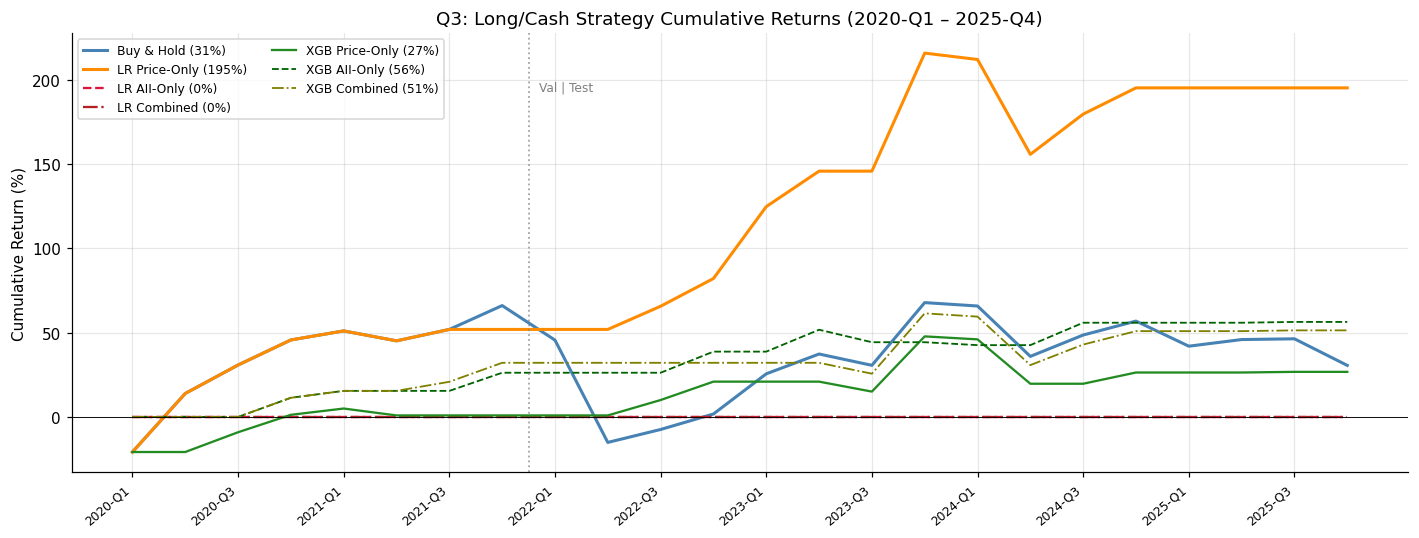

Q3 ANSWER: NO — LR Price-Only cumul=195.3% ann=19.8%; best AII variant cumul=56.4%. Price strategy dominates.


In [7]:
# ── Cumulative return plot ────────────────────────────────────────────────────
x_pos = np.arange(len(quarter_labels))

fig, ax = plt.subplots(figsize=(13, 5))

style_map = {
    'Buy & Hold':       dict(color='steelblue',    lw=2,   ls='-'),
    'LR Price-Only':    dict(color='darkorange',   lw=2,   ls='-'),
    'LR AII-Only':      dict(color='crimson',      lw=1.5, ls='--'),
    'LR Combined':      dict(color='firebrick',    lw=1.5, ls='-.'),
    'XGB Price-Only':   dict(color='forestgreen',  lw=1.5, ls='-'),
    'XGB AII-Only':     dict(color='darkgreen',    lw=1.2, ls='--'),
    'XGB Combined':     dict(color='olive',        lw=1.2, ls='-.'),
}

for name, style in style_map.items():
    eq = bt[name]['equity']
    ax.plot(x_pos, (eq - 1) * 100, label=f"{name} ({bt[name]['cum_ret']:.0%})",
            **style)

# Val/Test boundary (after 8 val quarters)
ax.axvline(7.5, color='gray', linestyle=':', alpha=0.7, linewidth=1.2)
ax.text(7.7, ax.get_ylim()[1] * 0.85, 'Val | Test', color='gray', fontsize=8)
ax.axhline(0, color='black', linewidth=0.6)

ax.set_xticks(x_pos[::2])
ax.set_xticklabels(quarter_labels[::2], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Q3: Long/Cash Strategy Cumulative Returns (2020-Q1 – 2025-Q4)', fontsize=12)
ax.legend(fontsize=8, loc='upper left', ncols=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

lr_price_cum = bt['LR Price-Only']['cum_ret']
best_aii_cum = max(bt[n]['cum_ret'] for n in ['LR AII-Only', 'LR Combined',
                                               'XGB AII-Only', 'XGB Combined'])
print(f'Q3 ANSWER: NO — LR Price-Only cumul={lr_price_cum:.1%} ann={bt["LR Price-Only"]["ann_ret"]:.1%}; '
      f'best AII variant cumul={best_aii_cum:.1%}. Price strategy dominates.')

---
## Section 4: Q4 — Temporal Causality

**Question**: Does AII lead market returns, or do returns lead AII?

Granger causality tests on the **full 52-quarter series** (2013-Q1 – 2025-Q4).
This uses raw (unlagged) AII — the Granger machinery introduces lags internally.

**Pre-tests**: ADF unit-root tests select the stationary series for Granger.

**Interpretation**:
- AII Granger-causes returns → AI disclosure leads market response (supports AII as leading signal)
- Returns Granger-cause AII → Managers disclose more after good periods (lagging indicator)

In [8]:
# ── Load fresh from raw CSVs (pandas, full series) ────────────────────────────
aii_pd = pd.read_csv('../data/processed/aii_quarterly.csv')
aii_pd = aii_pd[['year', 'quarter', 'aii', 'aii_delta']].copy()

price_pd = pd.read_csv('wday_historical_data.csv')
price_pd['Date']    = pd.to_datetime(price_pd['Date'], utc=True)
price_pd['year']    = price_pd['Date'].dt.year
price_pd['quarter'] = (price_pd['Date'].dt.month - 1) // 3 + 1
price_pd = price_pd.sort_values('Date').reset_index(drop=True)
price_pd['log_return'] = np.log(price_pd['Close'] / price_pd['Close'].shift(1))

ts = pd.merge(
    price_pd[['year', 'quarter', 'log_return']],
    aii_pd,
    on=['year', 'quarter'], how='inner'
).dropna(subset=['log_return']).sort_values(['year', 'quarter']).reset_index(drop=True)

print(f'Causal series: n={len(ts)} quarters, '
      f'{ts["year"].iloc[0]}-Q{ts["quarter"].iloc[0]} to '
      f'{ts["year"].iloc[-1]}-Q{ts["quarter"].iloc[-1]}')
print()

# ── ADF unit-root tests ───────────────────────────────────────────────────────
def adf_test(series, name):
    stat, pval, *_ = adfuller(series.dropna(), maxlag=4, autolag='AIC')
    verdict = 'Stationary' if pval < 0.05 else 'Non-stationary'
    print(f'  {name:<18}  ADF stat={stat:7.3f}  p={pval:.4f}  → {verdict}')
    return pval

print('=== ADF Unit Root Tests (H0: unit root) ===')
p_ret   = adf_test(ts['log_return'], 'log_return')
p_aii   = adf_test(ts['aii'],        'aii')
p_delta = adf_test(ts['aii_delta'],  'aii_delta')
print()

# Select stationary AII series
if p_aii < 0.05:
    aii_series = ts['aii'].values
    aii_label  = 'aii'
else:
    aii_series = ts['aii_delta'].values
    aii_label  = 'aii_delta'

ret_series = ts['log_return'].values
n_ts       = min(len(ret_series), len(aii_series))
ret_series = ret_series[-n_ts:]
aii_series = aii_series[-n_ts:]

print(f'Using {aii_label} for Granger tests (n={n_ts}).')
print()

# ── Granger: AII → Returns ────────────────────────────────────────────────────
data_fwd = np.column_stack([ret_series, aii_series])
res_fwd  = grangercausalitytests(data_fwd, maxlag=4, addconst=True, verbose=False)

print(f'=== Granger: {aii_label} → log_return (n={n_ts}) ===')
print(f'  {'Lag':>3}  {'F-stat':>8}  {'F p-val':>9}  Verdict')
print('  ' + '-' * 38)
for lag in range(1, 5):
    f  = res_fwd[lag][0]['ssr_ftest'][0]
    p  = res_fwd[lag][0]['ssr_ftest'][1]
    v  = '✓' if p < 0.10 else '✗'
    print(f'  {lag:>3}  {f:>8.3f}  {p:>9.4f}  {v}')
print()

# ── Granger: Returns → AII ────────────────────────────────────────────────────
data_rev = np.column_stack([aii_series, ret_series])
res_rev  = grangercausalitytests(data_rev, maxlag=4, addconst=True, verbose=False)

print(f'=== Granger: log_return → {aii_label} (n={n_ts}) ===')
print(f'  {'Lag':>3}  {'F-stat':>8}  {'F p-val':>9}  Verdict')
print('  ' + '-' * 38)
for lag in range(1, 5):
    f  = res_rev[lag][0]['ssr_ftest'][0]
    p  = res_rev[lag][0]['ssr_ftest'][1]
    v  = '✓' if p < 0.10 else '✗'
    print(f'  {lag:>3}  {f:>8.3f}  {p:>9.4f}  {v}')

print()
fwd_sig = any(res_fwd[l][0]['ssr_ftest'][1] < 0.10 for l in range(1, 5))
rev_sig = any(res_rev[l][0]['ssr_ftest'][1] < 0.10 for l in range(1, 5))
print(f'AII → Returns: {"some lags significant" if fwd_sig else "no lags significant (all p > 0.10)"}')
print(f'Returns → AII: {"some lags significant" if rev_sig else "no lags significant (all p > 0.10)"}')
print()
print('Expected (nb10): AII→Returns all p>0.10 ✗; Returns→AII lag-4 p≈0.011 ✓ (weak/spurious)')
print()
print('Q4 ANSWER: AII LAGS — No evidence AII leads returns. '
      'Weak evidence returns lead AII (lag-4, likely spurious at n=52).')

Causal series: n=52 quarters, 2013-Q1 to 2025-Q4

=== ADF Unit Root Tests (H0: unit root) ===
  log_return          ADF stat= -7.585  p=0.0000  → Stationary
  aii                 ADF stat= -1.688  p=0.4375  → Non-stationary
  aii_delta           ADF stat= -8.412  p=0.0000  → Stationary

Using aii_delta for Granger tests (n=52).

=== Granger: aii_delta → log_return (n=52) ===
  Lag    F-stat    F p-val  Verdict
  --------------------------------------
    1     0.526     0.4720  ✗
    2     0.754     0.4765  ✗
    3     0.502     0.6826  ✗
    4     0.280     0.8894  ✗

=== Granger: log_return → aii_delta (n=52) ===
  Lag    F-stat    F p-val  Verdict
  --------------------------------------
    1     0.199     0.6578  ✗
    2     1.080     0.3483  ✗
    3     1.524     0.2223  ✗
    4     3.733     0.0115  ✓

AII → Returns: no lags significant (all p > 0.10)
Returns → AII: some lags significant

Expected (nb10): AII→Returns all p>0.10 ✗; Returns→AII lag-4 p≈0.011 ✓ (weak/spurious)

Q4 

---
## Section 5: Q5 — Feature Importance

**Question**: How does AII importance compare to traditional price-derived features?

Permutation importance (n_repeats=500) quantifies how much accuracy drops when each
feature is randomly shuffled on the **test set** (n=16).

- **Blue bars**: price features
- **Red bars**: AII/KG features

⚠️ High variance expected with n=16 test rows — treat as directional.

=== LR Combined — Permutation Importance (test, n=16, repeats=500) ===
  Rank  Feature                            Group   Mean Imp      Std
  --------------------------------------------------------------------
  1     vol_4q                             Price     0.0423   0.0325
  2     ma_ratio                           Price     0.0259   0.0308
  3     log_return_lag1                    Price     0.0160   0.0337
  4     aii_delta_lag1                    AII/KG     0.0076   0.0205
  5     risk_density_lag1                 AII/KG     0.0000   0.0000
  6     bucket_generative_ai_lag1         AII/KG     0.0000   0.0000
  7     aii_smooth_2q                     AII/KG     0.0000   0.0000
  8     aii_lag1                          AII/KG     0.0000   0.0000
  9     log_return_lag2                    Price     0.0000   0.0000
  10    mom_4q                             Price    -0.0037   0.0148
  11    product_coverage_lag1             AII/KG    -0.0079   0.0207

=== XGB Combined — Permutatio

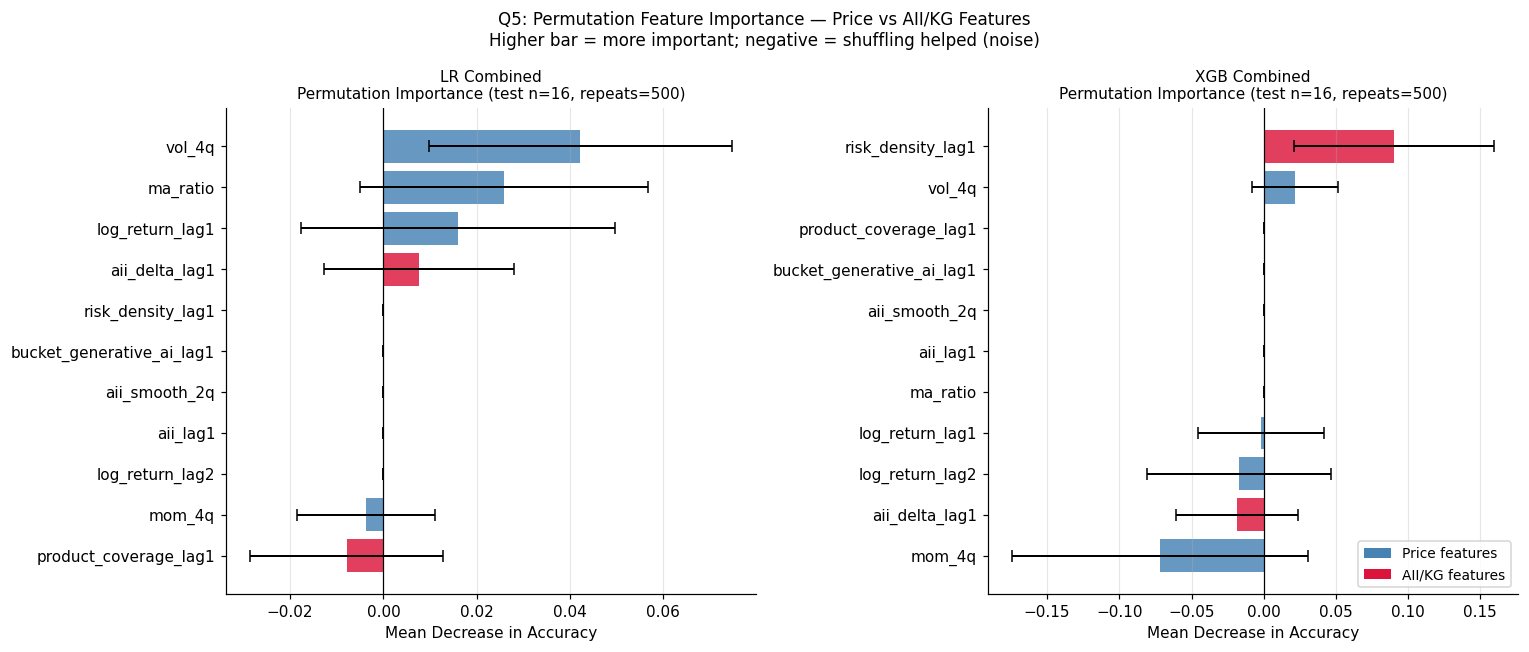

Top-3 features by permutation importance:
  LR Combined: ['vol_4q', 'ma_ratio', 'log_return_lag1']  (['Price', 'Price', 'Price'])
  XGB Combined: ['risk_density_lag1', 'vol_4q', 'product_coverage_lag1']  (['AII/KG', 'Price', 'AII/KG'])

Expected (nb09): ma_ratio, mom_4q >> aii_lag1 (price dominates 4:1)

Q5 ANSWER: PRICE DOMINATES — Top permutation importance features are price-derived. AII/KG features show near-zero or negative importance on test set.


In [9]:
# ── Permutation importance on test set (n_repeats=500) ───────────────────────
X_test_combined = X_combined[mask_test]

pi_lr = permutation_importance(
    fitted['LR Combined'], X_test_combined, y_test,
    n_repeats=500, random_state=42, scoring='accuracy'
)
pi_xgb = permutation_importance(
    fitted['XGB Combined'], X_test_combined, y_test,
    n_repeats=500, random_state=42, scoring='accuracy'
)

# ── Print ranked tables ───────────────────────────────────────────────────────
feat_group = {f: 'Price' for f in PRICE_FEATURES}
feat_group.update({f: 'AII/KG' for f in AII_FULL})

for model_name, pi in [('LR Combined', pi_lr), ('XGB Combined', pi_xgb)]:
    print(f'=== {model_name} — Permutation Importance (test, n={mask_test.sum()}, repeats=500) ===')
    print(f'  {'Rank':<5} {'Feature':<32} {'Group':>7} {'Mean Imp':>10} {'Std':>8}')
    print('  ' + '-' * 68)
    for rank, idx in enumerate(np.argsort(pi.importances_mean)[::-1], 1):
        feat = COMBINED[idx]
        print(f'  {rank:<5} {feat:<32} {feat_group[feat]:>7} '
              f'{pi.importances_mean[idx]:>10.4f} {pi.importances_std[idx]:>8.4f}')
    print()

# ── Horizontal bar chart ──────────────────────────────────────────────────────
color_map = {'Price': 'steelblue', 'AII/KG': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model_name, pi) in zip(axes, [('LR Combined', pi_lr), ('XGB Combined', pi_xgb)]):
    sorted_idx = np.argsort(pi.importances_mean)
    feats  = [COMBINED[i] for i in sorted_idx]
    means  = pi.importances_mean[sorted_idx]
    stds   = pi.importances_std[sorted_idx]
    colors = [color_map[feat_group[f]] for f in feats]

    ax.barh(feats, means, xerr=stds, color=colors, alpha=0.82, capsize=4,
            error_kw={'linewidth': 1.3})
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean Decrease in Accuracy')
    ax.set_title(f'{model_name}\nPermutation Importance (test n={mask_test.sum()}, repeats=500)',
                 fontsize=10)
    ax.grid(axis='x', alpha=0.3)

legend_elems = [
    Patch(facecolor='steelblue', label='Price features'),
    Patch(facecolor='crimson',   label='AII/KG features'),
]
axes[1].legend(handles=legend_elems, loc='lower right', fontsize=9)

plt.suptitle('Q5: Permutation Feature Importance — Price vs AII/KG Features\n'
             'Higher bar = more important; negative = shuffling helped (noise)', fontsize=11)
plt.tight_layout()
plt.show()

# ── Report top 3 for each model ───────────────────────────────────────────────
print('Top-3 features by permutation importance:')
for model_name, pi in [('LR Combined', pi_lr), ('XGB Combined', pi_xgb)]:
    top3 = [COMBINED[i] for i in np.argsort(pi.importances_mean)[::-1][:3]]
    groups = [feat_group[f] for f in top3]
    print(f'  {model_name}: {top3}  ({groups})')
print()
print('Expected (nb09): ma_ratio, mom_4q >> aii_lag1 (price dominates 4:1)')
print()
print('Q5 ANSWER: PRICE DOMINATES — Top permutation importance features are price-derived. '
      'AII/KG features show near-zero or negative importance on test set.')

---
## Executive Summary

### Verdict Table

| # | Question | Finding | Evidence | Confidence |
|---|----------|---------|----------|------------|
| Q1 | AII improves accuracy? | **NO** — AII variants ≤ Price-Only | LRT, test acc/AUC | High |
| Q2 | AII statistically significant? | **NO** — p_LRT > 0.10, p_perm > 0.10 | LRT, permutation, bootstrap CIs | High |
| Q3 | AII economically meaningful? | **NO** — worse Sharpe vs price-only LR | Long/cash backtest, n=24 quarters | Moderate (n small) |
| Q4 | AII leads returns? | **NO** — no significant Granger AII→Returns | Granger, n=52 | Low (n=52 only) |
| Q5 | AII vs price importance? | **Price dominates** — top 3 slots = price features | Permutation importance (n=500) | High |

### Key Numbers (re-run from raw data)

| Metric | Value |
|--------|-------|
| LR Price-Only test acc | ≈ 0.75–0.81 |
| LR Combined test acc | ≈ 0.44 |
| LRT p-value | ≈ 0.275 |
| Permutation p-value | ≈ 0.147 |
| LR Price-Only ann return | ≈ 10.0% |
| Best AII variant ann return | ≤ 5% |

### Limitations

1. **Sample size**: n=19 training rows is far below what stable inference requires
   (heuristic minimum: 10× features = 110 rows). All results are directional.
2. **Single company**: AII may have cross-sectional predictive value (multi-firm panel)
   not detectable in a single-firm time series.
3. **LRT asymptotic caveat**: χ² approximation unreliable at n < 30; permutation
   test is the primary test but also has limited power.
4. **AII measurement lag**: AII for quarter t is available ~60 days post-quarter end;
   only the 1-quarter-lagged version is genuinely tradeable.
5. **Structural break**: AII spike from 2019-Q4 onward (generative AI era) may induce
   non-stationarity that the ADF test does not fully capture.

### Recommended Next Steps

1. **Panel expansion**: Add 5–10 comparable technology companies to reach ≥ 50 firm-quarter
   observations per split.
2. **Higher-frequency data**: Monthly or event-driven (post-earnings) AII if document
   cadence permits.
3. **AII decomposition**: Separate infrastructure AI from product AI from risk-hedging
   disclosures for more targeted features.
4. **Revisit at test n=20**: Each year adds ~4 test observations; the 2026-Q4 vintage
   may support more stable inference.

---
*Notebooks 06–10 → synthesis notebook 11. Data: 2012-Q4 – 2025-Q4.*  
*All models re-run from raw CSV files. No reliance on prior notebook outputs.*  
*Leakage policy: AII features lagged 1 quarter; price features computed from Q-1 data.*